# Sleep Stage Classification

This notebook implements a machine learning pipeline to classify sleep stages from wearable physiological signals (BVP, ACC, TEMP, EDA, HR, IBI).  
The pipeline covers:
1. Environment setup & data download
2. Feature engineering (time-domain + frequency-domain)
3. Cross-validated LightGBM training (StratifiedGroupKFold)
4. Evaluation (F1-score, confusion matrix, feature importance)
5. Submission generation

---

## 1. Environment Setup
Check GPU availability and install all required dependencies.  
Key libraries:
- **LightGBM** — gradient-boosted tree classifier
- **SciPy** — signal processing (Welch PSD, statistics)
- **scikit-learn** — cross-validation, metrics, label encoding
- **tqdm** — progress bars for long loops

In [1]:
!nvidia-smi || true
!pip -q install kaggle lightgbm scipy scikit-learn pandas numpy tqdm seaborn matplotlib joblib

/bin/bash: line 1: nvidia-smi: command not found


## 2. Kaggle Authentication
Upload your `kaggle.json` API token and configure credentials so the Kaggle CLI can download competition data.

In [2]:
from google.colab import files
files.upload()  # Upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chanitnank","key":"9bac767ede91b547249a7a65cb042d14"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## 3. Data Download & Extraction
Download the competition dataset from Kaggle and extract all zip archives into the local data directory.

In [13]:
KAGGLE_COMPETITION = "super-ai-engineer-ss-6-sleep-stage-classification"
DATA_DIR = "/content/data"

import os
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle competitions download -c $KAGGLE_COMPETITION -p $DATA_DIR

100% 2.13G/2.13G [00:29<00:00, 77.5MB/s]



In [14]:
import glob
import zipfile
from pathlib import Path

zip_files = glob.glob(f"{DATA_DIR}/*.zip")
print("ZIP files found:", zip_files)

for z in zip_files:
    with zipfile.ZipFile(z, "r") as zf:
        zf.extractall(DATA_DIR)

print("\nExtracted top-level contents:")
for p in sorted(Path(DATA_DIR).glob("*")):
    print(" ", p)

ZIP files found: ['/content/data/super-ai-engineer-ss-6-sleep-stage-classification.zip']

Extracted top-level contents:
  /content/data/sample_submission.csv
  /content/data/super-ai-engineer-ss-6-sleep-stage-classification.zip
  /content/data/test_segment
  /content/data/train


## 4. Path Resolution
Dynamically locate the `train/`, `test_segment/`, and `sample_submission.csv` paths regardless of nested zip structures.

In [18]:
from pathlib import Path

def find_dir(root: str, name: str) -> Path | None:
    """Recursively find the first directory matching `name` under `root`."""
    for p in Path(root).rglob(name):
        if p.is_dir():
            return p
    return None

def find_file(root: str, name: str) -> Path | None:
    """Recursively find the first file matching `name` under `root`."""
    matches = list(Path(root).rglob(name))
    return matches[0] if matches else None

TRAIN_DIR        = find_dir(DATA_DIR, "train")
TEST_SEGMENT_DIR = find_dir(DATA_DIR, "test_segment")
SAMPLE_SUB_PATH  = find_file(DATA_DIR, "sample_submission.csv")

print("TRAIN_DIR       :", TRAIN_DIR)
print("TEST_SEGMENT_DIR:", TEST_SEGMENT_DIR)
print("SAMPLE_SUB_PATH :", SAMPLE_SUB_PATH)

TRAIN_DIR       : /content/data/train
TEST_SEGMENT_DIR: /content/data/test_segment
SAMPLE_SUB_PATH : /content/data/sample_submission.csv


## 5. Global Constants
Define shared configuration used throughout the pipeline:
- `FS = 16 Hz` — sensor sampling frequency
- `SEGMENT_LEN = 480` — 30-second window at 16 Hz
- `RAW_CHANNELS` — the 8 physiological signal columns
- `LABEL_COL` — target column name

In [19]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from tqdm.auto import tqdm

FS           = 16                     # Sampling frequency (Hz)
SEGMENT_LEN  = 30 * FS               # Samples per 30-second epoch = 480
RAW_CHANNELS = ["BVP", "ACC_X", "ACC_Y", "ACC_Z", "TEMP", "EDA", "HR", "IBI"]
LABEL_COL    = "Sleep_Stage"

## 6. Feature Engineering — Time-Domain Statistics
For each signal channel, compute 17 statistical descriptors that capture **distributional shape**, **variability**, and **temporal dynamics**:

| Feature | Description |
|---|---|
| mean, std, min, max, median | Central tendency & spread |
| q25, q75, iqr, mad | Robust spread metrics |
| skew, kurtosis | Distribution shape |
| energy | Signal power (mean of squares) |
| slope | Linear trend via polyfit |
| diff_mean, diff_std, absdiff_mean | First-order difference stats |
| autocorr_lag1 | Lag-1 autocorrelation (stationarity proxy) |

In [20]:
def safe_stats(x: np.ndarray, prefix: str) -> dict:
    """
    Compute 17 time-domain statistical features for a 1-D signal array.

    Parameters
    ----------
    x      : 1-D array-like signal values
    prefix : string prefix added to every feature key

    Returns
    -------
    dict of {feature_name: float}
    """
    x   = np.asarray(x, dtype=np.float32)
    dx  = np.diff(x)
    std = float(np.std(x))
    med = float(np.median(x))
    q25 = float(np.quantile(x, 0.25))
    q75 = float(np.quantile(x, 0.75))

    # Lag-1 autocorrelation — guard against zero-variance segments
    if len(x) > 1 and np.std(x[:-1]) > 1e-8 and np.std(x[1:]) > 1e-8:
        autocorr = float(np.corrcoef(x[:-1], x[1:])[0, 1])
    else:
        autocorr = 0.0

    return {
        f"{prefix}_mean"         : float(np.mean(x)),
        f"{prefix}_std"          : std,
        f"{prefix}_min"          : float(np.min(x)),
        f"{prefix}_max"          : float(np.max(x)),
        f"{prefix}_median"       : med,
        f"{prefix}_q25"          : q25,
        f"{prefix}_q75"          : q75,
        f"{prefix}_iqr"          : q75 - q25,
        f"{prefix}_mad"          : float(np.median(np.abs(x - med))),
        f"{prefix}_skew"         : float(skew(x))     if std > 1e-8 else 0.0,
        f"{prefix}_kurtosis"     : float(kurtosis(x)) if std > 1e-8 else 0.0,
        f"{prefix}_energy"       : float(np.mean(x ** 2)),
        f"{prefix}_slope"        : float(np.polyfit(np.arange(len(x)), x, 1)[0]),
        f"{prefix}_diff_mean"    : float(np.mean(dx))         if len(dx) else 0.0,
        f"{prefix}_diff_std"     : float(np.std(dx))          if len(dx) else 0.0,
        f"{prefix}_absdiff_mean" : float(np.mean(np.abs(dx))) if len(dx) else 0.0,
        f"{prefix}_autocorr_lag1": autocorr,
    }

## 7. Feature Engineering — Frequency-Domain (Welch PSD)
Estimate the Power Spectral Density using **Welch's method** and extract band-power features:

| Band | Frequency Range | Physiological Relevance |
|---|---|---|
| Very Low | 0.00 – 0.10 Hz | Slow respiration, thermoregulation |
| Low | 0.10 – 0.50 Hz | Respiration rate |
| Mid | 0.50 – 2.00 Hz | Heart rate variability |
| High | 2.00 – 5.00 Hz | Motion artifacts, HF-HRV |

Additionally computes **dominant peak frequency** and **spectral entropy** (uniformity of energy distribution).

In [21]:
FREQ_BANDS = {
    "very_low": (0.00, 0.10),
    "low"     : (0.10, 0.50),
    "mid"     : (0.50, 2.00),
    "high"    : (2.00, 5.00),
}

def welch_bandpowers(x: np.ndarray, fs: int, prefix: str) -> dict:
    """
    Compute absolute & relative band-power, dominant frequency, and
    spectral entropy via Welch's PSD estimate.

    Parameters
    ----------
    x      : 1-D signal array
    fs     : sampling frequency in Hz
    prefix : feature name prefix

    Returns
    -------
    dict of {feature_name: float}
    """
    x = np.asarray(x, dtype=np.float32)
    f, pxx = welch(x, fs=fs, nperseg=min(256, len(x)))
    total_power = float(np.trapz(pxx, f)) + 1e-12

    out = {}
    for name, (lo, hi) in FREQ_BANDS.items():
        mask = (f >= lo) & (f < hi)
        bp   = float(np.trapz(pxx[mask], f[mask])) if np.any(mask) else 0.0
        out[f"{prefix}_bp_{name}"]     = bp
        out[f"{prefix}_bp_{name}_rel"] = bp / total_power

    p_norm = pxx / (pxx.sum() + 1e-12)
    out[f"{prefix}_peak_freq"]   = float(f[np.argmax(pxx)])
    out[f"{prefix}_spec_entropy"] = float(-(p_norm * np.log(p_norm + 1e-12)).sum())
    return out

## 8. Feature Engineering — Segment Feature Extractor
Orchestrates all feature extraction for a single 30-second segment:
1. **Impute** NaN values per channel with the channel median
2. **Derive** `ACC_MAG` = √(X² + Y² + Z²) as a motion-magnitude signal
3. Apply `safe_stats` to all 9 channels (8 raw + ACC_MAG)
4. Apply `welch_bandpowers` to BVP, EDA, and ACC_MAG
5. Compute **cross-channel correlations** (HR↔IBI, BVP↔HR, EDA↔TEMP)
6. Compute **activity ratio** — fraction of ACC_MAG samples above 75th percentile

In [22]:
SPECTRAL_CHANNELS = ["BVP", "EDA", "ACC_MAG"]

CROSS_CORR_PAIRS = [
    ("HR",  "IBI",  "HR_IBI_corr"),
    ("BVP", "HR",   "BVP_HR_corr"),
    ("EDA", "TEMP", "EDA_TEMP_corr"),
]

def extract_segment_features(df_seg: pd.DataFrame) -> dict:
    """
    Extract all time-domain, frequency-domain, and cross-channel features
    from a single 30-second sensor segment.

    Parameters
    ----------
    df_seg : DataFrame with columns == RAW_CHANNELS, length == SEGMENT_LEN

    Returns
    -------
    dict of {feature_name: float}
    """
    x = df_seg.copy()

    # --- 1. Coerce to numeric & median-impute NaNs ---
    for c in RAW_CHANNELS:
        x[c] = pd.to_numeric(x[c], errors="coerce")
        med  = x[c].median()
        x[c] = x[c].fillna(med if pd.notnull(med) else 0.0)

    # --- 2. Derived channel: 3-axis acceleration magnitude ---
    x["ACC_MAG"] = np.sqrt(
        x["ACC_X"].values**2 + x["ACC_Y"].values**2 + x["ACC_Z"].values**2
    )

    feats = {}

    # --- 3. Time-domain statistics for every channel ---
    for c in RAW_CHANNELS + ["ACC_MAG"]:
        feats.update(safe_stats(x[c].values, c))

    # --- 4. Frequency-domain features for key channels ---
    for c in SPECTRAL_CHANNELS:
        feats.update(welch_bandpowers(x[c].values, FS, c))

    # --- 5. Cross-channel Pearson correlations ---
    for c1, c2, key in CROSS_CORR_PAIRS:
        if x[c1].std() > 1e-8 and x[c2].std() > 1e-8:
            feats[key] = float(np.corrcoef(x[c1], x[c2])[0, 1])
        else:
            feats[key] = 0.0

    # --- 6. Activity-level proxy features ---
    acc_mag = x["ACC_MAG"].values
    feats["ACC_MAG_above_p75_ratio"] = float((acc_mag > np.quantile(acc_mag, 0.75)).mean())
    feats["ACC_AXIS_STD_SUM"]        = float(x["ACC_X"].std() + x["ACC_Y"].std() + x["ACC_Z"].std())

    return feats

## 9. Dataset Construction — Parallel Feature Extraction
Build feature matrices for train and test sets.

**Optimizations applied:**
- `joblib.Parallel` with `n_jobs=-1` uses all CPU cores for parallel file processing
- Each subject/file is processed independently, so parallelization is embarrassingly parallel
- No global state is mutated — results are collected and concatenated after all workers finish

In [23]:
from joblib import Parallel, delayed

# ── Train ──────────────────────────────────────────────────────────────────
def _process_train_file(fp: Path) -> list[dict]:
    """Process one training subject file → list of segment feature dicts."""
    df = pd.read_csv(fp)
    rows = []
    n_segs = len(df) // SEGMENT_LEN
    for seg_idx in range(n_segs):
        s   = seg_idx * SEGMENT_LEN
        seg = df.iloc[s : s + SEGMENT_LEN].reset_index(drop=True)
        feats = extract_segment_features(seg[RAW_CHANNELS])
        feats["subject_id"]   = fp.stem
        feats["segment_idx"]  = seg_idx
        feats["target"]       = seg[LABEL_COL].iloc[0]
        rows.append(feats)
    return rows

def build_train_features(train_files: list[Path], n_jobs: int = -1) -> pd.DataFrame:
    """
    Extract features from all training subject files in parallel.

    Parameters
    ----------
    train_files : list of Path objects pointing to per-subject CSVs
    n_jobs      : number of parallel workers (-1 = all cores)

    Returns
    -------
    DataFrame where each row is one 30-second segment
    """
    results = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(_process_train_file)(fp)
        for fp in tqdm(train_files, desc="Train subjects")
    )
    rows = [r for sublist in results for r in sublist]  # flatten
    return pd.DataFrame(rows)


# ── Test ───────────────────────────────────────────────────────────────────
def _process_test_file(fp: Path) -> dict:
    """Process one test segment file → single feature dict."""
    df  = pd.read_csv(fp)
    assert len(df) == SEGMENT_LEN, f"Unexpected segment length in {fp}"
    feats = extract_segment_features(df[RAW_CHANNELS])
    feats["subject_id"]  = fp.parent.name
    feats["segment_idx"] = int(fp.stem.split("_")[-1])
    feats["id"]          = fp.stem
    return feats

def build_test_features(test_files: list[Path], n_jobs: int = -1) -> pd.DataFrame:
    """
    Extract features from all test segment files in parallel.

    Parameters
    ----------
    test_files : list of Path objects pointing to per-segment CSVs
    n_jobs     : number of parallel workers (-1 = all cores)

    Returns
    -------
    DataFrame where each row is one test segment
    """
    rows = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(_process_test_file)(fp)
        for fp in tqdm(test_files, desc="Test segments")
    )
    return pd.DataFrame(rows)

## 10. Run Feature Extraction
Discover all CSV files and run the parallel extraction pipeline. Timing is reported for train and test separately.

In [24]:
import time

train_files = sorted(Path(TRAIN_DIR).rglob("train*.csv"))
test_files  = sorted(Path(TEST_SEGMENT_DIR).rglob("test*.csv"))

print(f"Train files : {len(train_files)}")
print(f"Test files  : {len(test_files)}")

t0 = time.time()
train_feat = build_train_features(train_files)
print(f"Train extraction : {(time.time()-t0)/60:.2f} min  |  shape={train_feat.shape}")

t0 = time.time()
test_feat = build_test_features(test_files)
print(f"Test  extraction : {(time.time()-t0)/60:.2f} min  |  shape={test_feat.shape}")

display(train_feat.head())
display(test_feat.head())

Train files : 83
Test files  : 7832


Train subjects:   0%|          | 0/83 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
/tmp/ipykernel_16400/2604046885.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = float(np.trapz(pxx, f)) + 1e-12
/tmp/ipykernel_16400/2604046885.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bp   = float(np.trapz(pxx[mask], f[mask])) if np.any(mask) else 0.0
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/tmp/ipykernel_16400/2604046885.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = float(np.trapz(pxx, f)) + 1e-12
/tmp/ipykernel_16400/2604046885.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instea

Train extraction : 57.47 min  |  shape=(66745, 191)


Test segments:   0%|          | 0/7832 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
/tmp/ipykernel_16400/2604046885.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = float(np.trapz(pxx, f)) + 1e-12
/tmp/ipykernel_16400/2604046885.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bp   = float(np.trapz(pxx[mask], f[mask])) if np.any(mask) else 0.0
/tmp/ipykernel_16400/2604046885.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = float(np.trapz(pxx, f)) + 1e-12
/tmp/ipykernel_16400/2604046885.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bp   = float(np.trapz(pxx[mask], f[mask])) if np.any(mask) else 0.0
/tmp/ipykerne

Test  extraction : 7.52 min  |  shape=(7832, 191)


,BVP_mean,BVP_std,BVP_min,BVP_max,BVP_median,BVP_q25,BVP_q75,BVP_iqr,BVP_mad,BVP_skew,...,ACC_MAG_peak_freq,ACC_MAG_spec_entropy,HR_IBI_corr,BVP_HR_corr,EDA_TEMP_corr,ACC_MAG_above_p75_ratio,ACC_AXIS_STD_SUM,subject_id,segment_idx,target
0,2.816168,155.888290,-1212.411743,665.980835,1.940699,-11.156508,34.338478,45.494987,16.669035,-2.017461,...,1.8125,4.383562,-0.669079,0.035622,-0.158872,0.25,9.540941,train001,0,W
1,-2.661875,123.138374,-729.854614,466.121246,1.047080,-28.886623,38.463120,67.349743,34.460030,-1.671969,...,5.3125,4.514414,0.000000,0.045890,0.080881,0.25,4.590161,train001,1,W
2,-0.244761,52.886585,-184.643387,154.234161,2.691504,-22.407476,27.584063,49.991539,25.143280,-0.552818,...,0.7500,4.481052,0.743450,-0.007154,-0.113080,0.25,1.856977,train001,2,W
3,0.004560,76.540405,-344.279602,229.873627,5.574753,-37.435513,44.803623,82.239136,41.783890,-0.829661,...,1.3125,4.472763,0.000000,0.004576,-0.153544,0.25,2.625103,train001,3,W
4,-0.944101,153.643417,-552.651489,583.380249,5.572555,-50.273239,42.142277,92.415516,44.680298,0.077832,...,0.1250,4.426127,0.083978,0.003510,0.051881,0.25,6.771115,train001,4,W


,BVP_mean,BVP_std,BVP_min,BVP_max,BVP_median,BVP_q25,BVP_q75,BVP_iqr,BVP_mad,BVP_skew,...,ACC_MAG_peak_freq,ACC_MAG_spec_entropy,HR_IBI_corr,BVP_HR_corr,EDA_TEMP_corr,ACC_MAG_above_p75_ratio,ACC_AXIS_STD_SUM,subject_id,segment_idx,id
0,2.436632,96.985413,-502.470276,412.153778,8.922092,-37.086006,48.175610,85.261616,41.162712,-0.228703,...,4.1875,4.368460,-0.858841,0.011924,-0.367599,0.25,3.159009,test001,0,test001_00000
1,-0.224025,52.860653,-158.916641,71.545494,15.325783,-33.858391,42.803200,76.661591,32.345276,-0.830855,...,0.4375,4.117645,0.016579,0.010236,-0.238399,0.25,0.853041,test001,1,test001_00001
2,0.453667,47.620884,-136.080170,68.509758,13.493460,-31.190311,38.141541,69.331852,29.625450,-0.812414,...,0.8750,4.359073,0.019260,-0.021719,-0.017702,0.25,0.643492,test001,2,test001_00002
3,-0.237769,49.324604,-118.424660,61.473942,13.961334,-35.452339,41.395458,76.847797,31.693710,-0.759333,...,0.8750,4.342312,0.049513,-0.020129,-0.238262,0.25,0.596129,test001,3,test001_00003
4,0.406600,62.359196,-421.064880,282.361389,10.670238,-31.745293,36.496231,68.241524,30.276482,-0.732493,...,0.1875,4.018368,-0.251141,0.031277,-0.356502,0.25,1.447156,test001,4,test001_00004


## 11. Prepare Training Data
Encode the multi-class sleep stage labels with `LabelEncoder` and separate features from metadata columns.

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_feat["y"] = le.fit_transform(train_feat["target"])

META_COLS    = {"subject_id", "segment_idx", "target", "y", "id"}
feature_cols = [c for c in train_feat.columns if c not in META_COLS]

X      = train_feat[feature_cols].values.astype(np.float32)
y      = train_feat["y"].values
groups = train_feat["subject_id"].values
X_test = test_feat[feature_cols].values.astype(np.float32)

print("Sleep stage labels :", list(le.classes_))
print("Number of features :", len(feature_cols))
print("Train samples      :", len(X))
print("Test  samples      :", len(X_test))

Sleep stage labels : ['N1', 'N2', 'N3', 'R', 'W']
Number of features : 188
Train samples      : 66745
Test  samples      : 7832


## 12. Model Definition — LightGBM with StratifiedGroupKFold
**LightGBM** is chosen for its speed, native handling of class imbalance (`class_weight='balanced'`), and strong tabular performance.

**StratifiedGroupKFold** ensures:
- Subject-level data leakage prevention (all segments from a subject stay in the same fold)
- Class distribution is preserved across folds

Key hyperparameters:

| Parameter | Value | Rationale |
|---|---|---|
| `learning_rate` | 0.03 | Small LR + more trees = better generalization |
| `n_estimators` | 3000 | Controlled by early stopping |
| `num_leaves` | 63 | Moderate complexity |
| `early_stopping` | 200 rounds | Prevent overfitting |
| `class_weight` | balanced | Compensate for class imbalance |

In [26]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import lightgbm as lgb

N_SPLITS = 5
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

LGBM_PARAMS = {
    "objective"       : "multiclass",
    "num_class"       : len(le.classes_),
    "learning_rate"   : 0.03,
    "n_estimators"    : 3000,
    "num_leaves"      : 63,
    "max_depth"       : -1,
    "min_child_samples": 40,
    "subsample"       : 0.8,
    "subsample_freq"  : 1,
    "colsample_bytree": 0.8,
    "reg_alpha"       : 0.5,
    "reg_lambda"      : 1.0,
    "class_weight"    : "balanced",
    "random_state"    : 42,
    "n_jobs"          : -1,
    "verbose"         : -1,
}

## 13. Cross-Validation Training
Train one LightGBM model per fold using early stopping.  
- **Out-of-fold (OOF) predictions** are accumulated for unbiased CV evaluation
- **Test predictions** are averaged across all folds (ensemble by averaging probabilities)

In [27]:
n_classes  = len(le.classes_)
oof_pred   = np.zeros((len(X),      n_classes), dtype=np.float32)
test_pred  = np.zeros((len(X_test), n_classes), dtype=np.float32)
fold_scores = []
models      = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups), 1):
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set    = [(X_va, y_va)],
        eval_metric = "multi_logloss",
        callbacks   = [
            lgb.early_stopping(200, verbose=False),
            lgb.log_evaluation(100),
        ],
    )

    va_proba = model.predict_proba(X_va)
    score    = f1_score(y_va, va_proba.argmax(axis=1), average="weighted")

    oof_pred[va_idx]  = va_proba
    test_pred        += model.predict_proba(X_test) / N_SPLITS
    fold_scores.append(score)
    models.append(model)

    print(f"Fold {fold}/{N_SPLITS}  |  Weighted F1 = {score:.6f}  |  Best iter = {model.best_iteration_}")

print(f"\nMean CV Weighted F1: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")

[100]	valid_0's multi_logloss: 1.31207
[200]	valid_0's multi_logloss: 1.262
[300]	valid_0's multi_logloss: 1.24803
[400]	valid_0's multi_logloss: 1.24576
[500]	valid_0's multi_logloss: 1.24685
[600]	valid_0's multi_logloss: 1.25114


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1/5  |  Weighted F1 = 0.488010  |  Best iter = 450
[100]	valid_0's multi_logloss: 1.29599
[200]	valid_0's multi_logloss: 1.25093
[300]	valid_0's multi_logloss: 1.23881
[400]	valid_0's multi_logloss: 1.23806
[500]	valid_0's multi_logloss: 1.24387


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2/5  |  Weighted F1 = 0.483396  |  Best iter = 350
[100]	valid_0's multi_logloss: 1.32965
[200]	valid_0's multi_logloss: 1.32481
[300]	valid_0's multi_logloss: 1.34972


...

Fold 3/5  |  Weighted F1 = 0.449463  |  Best iter = 137
[100]	valid_0's multi_logloss: 1.36071
[200]	valid_0's multi_logloss: 1.37436
[300]	valid_0's multi_logloss: 1.41799


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4/5  |  Weighted F1 = 0.434691  |  Best iter = 129
[100]	valid_0's multi_logloss: 1.2621
[200]	valid_0's multi_logloss: 1.21643
[300]	valid_0's multi_logloss: 1.2159
[400]	valid_0's multi_logloss: 1.22451


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5/5  |  Weighted F1 = 0.499985  |  Best iter = 264

Mean CV Weighted F1: 0.471109 ± 0.024760


## 14. Evaluation — OOF Metrics
Evaluate the full out-of-fold predictions against ground truth.  
OOF metrics provide an unbiased estimate of generalization performance because each segment was scored by a model that never saw it during training.

In [28]:
oof_cls = oof_pred.argmax(axis=1)

weighted_f1 = f1_score(y, oof_cls, average="weighted")
macro_f1    = f1_score(y, oof_cls, average="macro")

print(f"OOF Weighted F1 : {weighted_f1:.6f}")
print(f"OOF Macro F1    : {macro_f1:.6f}")
print(f"Fold scores     : {[f'{s:.4f}' for s in fold_scores]}")
print()
print(classification_report(y, oof_cls, target_names=le.classes_))

OOF Weighted F1 : 0.471121
OOF Macro F1    : 0.318800
Fold scores     : ['0.4880', '0.4834', '0.4495', '0.4347', '0.5000']

              precision    recall  f1-score   support

          N1       0.19      0.24      0.21      7753
          N2       0.63      0.57      0.60     33786
          N3       0.25      0.05      0.09      2345
           R       0.23      0.18      0.20      7033
           W       0.44      0.57      0.50     15828

    accuracy                           0.47     66745
   macro avg       0.35      0.32      0.32     66745
weighted avg       0.48      0.47      0.47     66745



## 15. Confusion Matrix Visualization
Row-normalized confusion matrix shows the **recall per class** — how well the model identifies each sleep stage.  
Values close to 1.0 on the diagonal indicate high per-class accuracy.

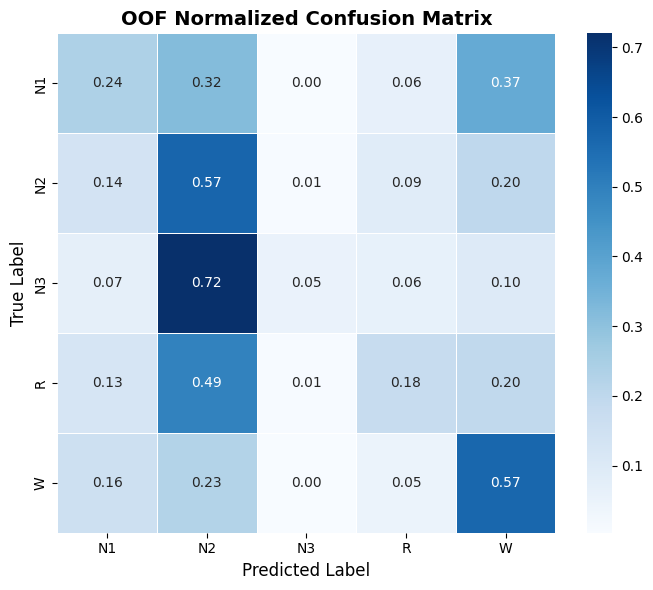

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y, oof_cls, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
    linewidths=0.4, linecolor="white"
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
ax.set_title("OOF Normalized Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 16. Feature Importance
Display the top-50 most important features from the last fold's model (gain-based importance).  
This reveals which physiological signals and frequency bands are most discriminative for sleep stage classification.

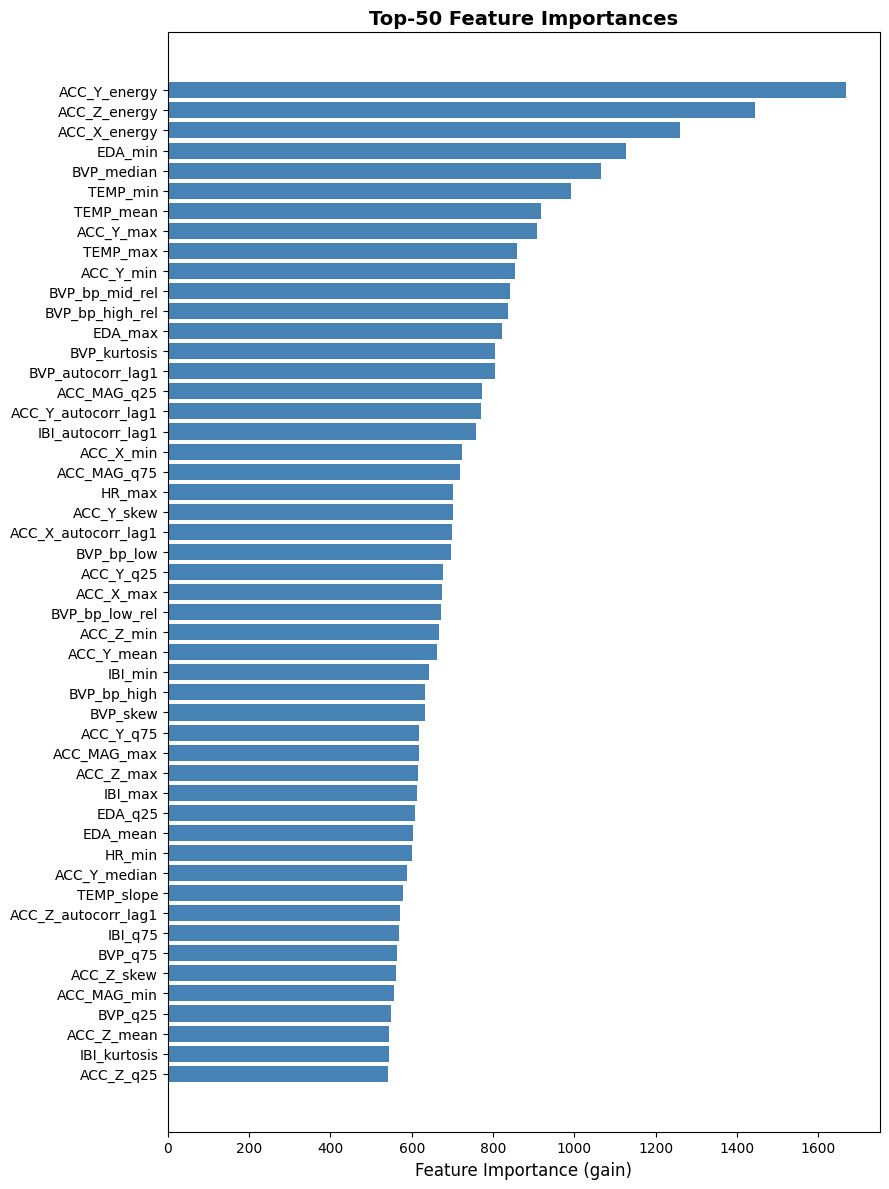

,feature,importance
0,ACC_Y_energy,1669
1,ACC_Z_energy,1446
2,ACC_X_energy,1260
3,EDA_min,1127
4,BVP_median,1065
5,TEMP_min,992
6,TEMP_mean,918
7,ACC_Y_max,908
8,TEMP_max,858
9,ACC_Y_min,853


In [30]:
imp = (
    pd.DataFrame({"feature": feature_cols, "importance": models[-1].feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Top-50 bar chart
top50 = imp.head(50)
fig, ax = plt.subplots(figsize=(9, 12))
ax.barh(top50["feature"][::-1], top50["importance"][::-1], color="steelblue")
ax.set_xlabel("Feature Importance (gain)", fontsize=12)
ax.set_title("Top-50 Feature Importances", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

display(imp.head(50))

## 17. Generate Submission
Decode the averaged test probabilities back to class labels using the fitted `LabelEncoder`, merge with the sample submission template to ensure correct ordering, and save to `/content/submission_lgbm.csv`.

In [31]:
sample_sub  = pd.read_csv(SAMPLE_SUB_PATH)
pred_labels = le.inverse_transform(test_pred.argmax(axis=1))

pred_df    = test_feat[["id"]].copy()
pred_df["labels"] = pred_labels

submission = sample_sub[["id"]].merge(pred_df, on="id", how="left")

n_missing = submission["labels"].isna().sum()
assert n_missing == 0, f"{n_missing} missing predictions — check test segment IDs"

submission.to_csv("/content/submission_lgbm.csv", index=False)

print(f"Submission saved: {len(submission)} rows")
print("Label distribution:")
print(submission["labels"].value_counts())
display(submission.head(10))

Submission saved: 7832 rows
Label distribution:
labels
N2    4637
W     2098
N1     907
R      176
N3      14
Name: count, dtype: int64


,id,labels
0,test001_00000,W
1,test001_00001,N1
2,test001_00002,N2
3,test001_00003,N2
4,test001_00004,W
5,test001_00005,N2
6,test001_00006,W
7,test001_00007,W
8,test001_00008,N1
9,test001_00009,W
